# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [2]:
class Player:
    def __init__(self, name, starting_chips=1000):
        self.name = name
        self.chips = starting_chips
        self.hand = []
        
        # Storing the bet on the player object so we can easily calculate 
        # payouts or losses at the end of the round.
        self.current_bet = 0 
        
    def receive_card(self, card):
        self.hand.append(card)

    def calculate_score(self):
        """Calculates the best possible hand value."""
        score = 0
        aces = 0
        
        # Logic: It's easier to assume all Aces are 11s initially. 
        # We can just downgrade them to 1s later if the total goes over 21.
        for card in self.hand:
            if card.rank in ['J', 'Q', 'K']:
                score += 10
            elif card.rank == 'A':
                aces += 1
                score += 11
            else:
                score += int(card.rank)
                
        # If we bust, check if we have an Ace we can shrink from 11 to 1.
        # We subtract 10 for each Ace we convert until we are safe.
        while score > 21 and aces > 0:
            score -= 10
            aces -= 1
            
        return score
        
    def clear_hand(self):
        # Resetting for the next simulation round
        self.hand = []
        self.current_bet = 0


class Dealer(Player):
    # The dealer is just a player with forced actions, so inheritance makes sense here.
    def __init__(self):
        super().__init__("Dealer", starting_chips=0) # Dealer chips don't matter

    def should_hit(self):
        # Assignment requirement: Dealer hits on 16 and stands on 17.
        # Returning True means "Hit", False means "Stand".
        return self.calculate_score() < 17

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [3]:
class Card:
    """Represents a single playing card."""
    def __init__(self, rank, suit):
        # Storing basic card properties. 
        self.rank = rank
        self.suit = suit

    def __str__(self):
        pass

    def __repr__(self):
        pass


class Deck:
    """Manages the shoe of multiple decks."""
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        # Using a list to hold Card objects so we maintain drawing order
        self.cards = [] 
        # Flag to tell the Game loop when the plastic card was hit
        self.needs_reshuffle = False 

    def build_deck(self):
        pass

    def shuffle(self):
        pass

    def draw(self):
        pass


class Player:
    def __init__(self, name, strategy="Human", starting_chips=1000):
        self.name = name
        self.chips = starting_chips
        self.current_bet = 0
        self.hand = []
        self.strategy = strategy 

    def receive_card(self, card):
        self.hand.append(card)

    def calculate_score(self):
        score = 0
        aces = 0
        
        for card in self.hand:
            if card.rank in ['J', 'Q', 'K']:
                score += 10
            elif card.rank == 'A':
                aces += 1
                score += 11
            else:
                score += int(card.rank)
                
        while score > 21 and aces > 0:
            score -= 10
            aces -= 1
            
        return score

    def clear_hand(self):
        self.hand = []
        self.current_bet = 0

    def place_bet(self):
        """Routes betting logic based on player strategy."""
        if self.strategy == "Human":
            while True:
                try:
                    bet = int(input(f"{self.name}, you have {self.chips} chips. Enter bet: "))
                    if 0 < bet <= self.chips:
                        self.current_bet = bet
                        self.chips -= bet
                        break
                    else:
                        print("Invalid amount. Must be greater than 0.")
                except ValueError:
                    print("Please enter a valid number.")
        else:
            # Automated bot logic: Always bet 10 chips to keep the simulation simple
            if self.chips > 0:
                bet = 10 if self.chips >= 10 else self.chips
                self.current_bet = bet
                self.chips -= bet

    def decide_action(self, dealer_upcard, true_count):
        """Routes hitting/standing logic based on player strategy."""
        if self.strategy == "Human":
            while True:
                choice = input(f"Your score is {self.calculate_score()}. Hit or Stand? (h/s): ").lower()
                if choice in ['h', 's']:
                    return "Hit" if choice == 'h' else "Stand"
                print("Invalid input. Please type 'h' or 's'.")
                
        elif self.strategy == "Dealer":
            # Dealer bots ignore the true_count and just hit if under 17
            if self.calculate_score() < 17:
                return "Hit"
            return "Stand"


class Dealer(Player):
    """The dealer is a specific type of player with fixed rules."""
    def __init__(self):
        # Calling the parent Player __init__, but hardcoding the name and strategy.
        # Dealers don't need chips, so we set it to 0.
        super().__init__(name="Dealer", strategy="Fixed Rules", starting_chips=0)

    def should_hit(self):
        # This will override normal player logic since the dealer must hit on 16.
        pass


class Game:
    """The central controller that runs the simulation."""
    def __init__(self, num_players=1, decks_in_shoe=6):
        # Aggregating our other classes here to build the actual table environment
        self.deck = Deck(num_decks=decks_in_shoe)
        self.dealer = Dealer()
        self.players = []
        
        # Tracking the global card counting state
        self.running_count = 0
        self.true_count = 0.0

    def update_count(self, card):
        # This will adjust the running_count based on the drawn card's value
        pass

    def play_round(self):
        # This will handle the sequence: bets -> deal -> player turns -> dealer turn -> payouts
        pass

    def run_simulation(self, num_games):
        # The main loop to run play_round() thousands of times for our data analysis
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [4]:
import random

class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
    def __str__(self): return f"{self.rank} of {self.suit}"
    def __repr__(self): return self.__str__()

class Deck:
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']

    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.needs_reshuffle = False
        self.build_deck()
        self.shuffle()

    def build_deck(self):
        self.cards = [Card(rank, suit) for _ in range(self.num_decks) for suit in self.suits for rank in self.ranks]

    def shuffle(self):
        random.shuffle(self.cards)
        self.needs_reshuffle = False
        total_cards = len(self.cards)
        insert_idx = random.randint(total_cards // 2, int(total_cards * 0.85))
        self.cards.insert(insert_idx, "PLASTIC_CARD")

    def draw(self):
        if not self.cards:
            self.build_deck()
            self.shuffle()
        drawn_item = self.cards.pop(0)
        if drawn_item == "PLASTIC_CARD":
            self.needs_reshuffle = True
            return self.draw()
        return drawn_item

class Player:
    def __init__(self, name, strategy="Human", starting_chips=1000):
        self.name = name
        self.chips = starting_chips
        self.current_bet = 0
        self.hand = []
        self.strategy = strategy 

    def receive_card(self, card):
        self.hand.append(card)

    def calculate_score(self):
        score = 0
        aces = 0
        for card in self.hand:
            if card.rank in ['J', 'Q', 'K']: score += 10
            elif card.rank == 'A':
                aces += 1
                score += 11
            else: score += int(card.rank)
                
        while score > 21 and aces > 0:
            score -= 10
            aces -= 1
        return score

    def clear_hand(self):
        self.hand = []
        self.current_bet = 0

    def place_bet(self, true_count=0.0):
        if self.chips <= 0:
            self.current_bet = 0
            return 

        if self.strategy == "Human":
            while True:
                try:
                    bet = int(input(f"{self.name}, you have {self.chips} chips. Enter bet: "))
                    if 0 < bet <= self.chips:
                        self.current_bet = bet
                        self.chips -= bet
                        break
                    else: print("Invalid amount.")
                except ValueError: print("Please enter a valid number.")
        elif self.strategy == "Counter":
            if true_count >= 2.0: bet = 50 if self.chips >= 50 else self.chips
            else: bet = 10 if self.chips >= 10 else self.chips
            self.current_bet = bet
            self.chips -= bet
        else:
            bet = 10 if self.chips >= 10 else self.chips
            self.current_bet = bet
            self.chips -= bet

    # CRITICAL FIX: The base player now officially accepts running_count
    def decide_action(self, dealer_upcard, true_count, running_count=0):
        if self.strategy == "Human":
            while True:
                choice = input(f"Your score is {self.calculate_score()}. Hit or Stand? (h/s): ").lower()
                if choice in ['h', 's']: return "Hit" if choice == 'h' else "Stand"
                print("Invalid input.")
        elif self.strategy == "Dealer":
            if self.calculate_score() < 17: return "Hit"
            return "Stand"
        elif self.strategy == "Counter":
            dealer_val = 10 if dealer_upcard.rank in ['J', 'Q', 'K', 'A'] else int(dealer_upcard.rank)
            score = self.calculate_score()
            if score >= 17: return "Stand"
            elif score >= 12 and dealer_val <= 6: return "Stand"
            else: return "Hit"

class Dealer(Player):
    def __init__(self):
        super().__init__(name="Dealer", strategy="Fixed Rules", starting_chips=0)
    def should_hit(self):
        return self.calculate_score() < 17

class Lab6Player(Player):
    def __init__(self, name, starting_chips=1000, hit_threshold=-1):
        super().__init__(name=name, strategy="Count_Action", starting_chips=starting_chips)
        self.hit_threshold = hit_threshold

    def decide_action(self, dealer_upcard, true_count, running_count=0):
        if self.calculate_score() >= 21: return "Stand"
        if running_count <= self.hit_threshold: return "Hit"
        else: return "Stand"

class Game:
    def __init__(self, players_list, decks_in_shoe=6, verbose=True):
        self.deck = Deck(num_decks=decks_in_shoe)
        self.dealer = Dealer()
        self.players = players_list 
        self.running_count = 0
        self.true_count = 0.0
        self.verbose = verbose 

    def update_count(self, card):
        if card.rank in ['2', '3', '4', '5', '6']: self.running_count += 1
        elif card.rank in ['10', 'J', 'Q', 'K', 'A']: self.running_count -= 1
        decks_remaining = max(1, len(self.deck.cards) / 52)
        self.true_count = self.running_count / decks_remaining

    def deal_and_count(self, person):
        card = self.deck.draw()
        self.update_count(card)
        person.receive_card(card)

    def play_round(self):
        if self.verbose: print("\n--- NEW ROUND ---")
        if self.deck.needs_reshuffle:
            if self.verbose: print("Dealer is shuffling the shoe...")
            self.deck.build_deck()
            self.deck.shuffle()
            self.running_count = 0 
            self.true_count = 0.0

        for player in self.players: 
            if player.chips > 0: player.place_bet(self.true_count)

        for _ in range(2):
            for player in self.players: 
                if player.current_bet > 0: self.deal_and_count(player)
            self.deal_and_count(self.dealer)

        if self.verbose: print(f"Dealer shows: {self.dealer.hand[0]} (Hidden Card)")

        for player in self.players:
            if player.current_bet == 0: continue
            if self.verbose: print(f"\n{player.name}'s turn. Hand: {player.hand}")
            while player.calculate_score() < 21:
                action = player.decide_action(self.dealer.hand[0], self.true_count, self.running_count)
                if action == "Hit":
                    self.deal_and_count(player)
                    if self.verbose: print(f"Drew a card. Hand: {player.hand}")
                else: break
            if player.calculate_score() > 21 and self.verbose: print(f"{player.name} BUSTS!")

        if self.verbose: print(f"\nDealer's turn. Hand reveals: {self.dealer.hand}")
        while self.dealer.should_hit():
            self.deal_and_count(self.dealer)
            if self.verbose: print(f"Dealer hits. Hand: {self.dealer.hand}")

        dealer_score = self.dealer.calculate_score()

        for player in self.players:
            if player.current_bet == 0: continue
            player_score = player.calculate_score()
            if player_score <= 21:
                if dealer_score > 21 or player_score > dealer_score:
                    player.chips += (player.current_bet * 2)
                    if self.verbose: print(f"{player.name} WINS!")
                elif player_score == dealer_score:
                    player.chips += player.current_bet
                    if self.verbose: print(f"{player.name} PUSHES.")
                else: 
                    if self.verbose: print(f"{player.name} LOSES.")
            else:
                if self.verbose: print(f"{player.name} LOSES.")
            player.clear_hand()
            
        self.dealer.clear_hand()

    def run_simulation(self, num_games=1, target_player_name=None):
        for i in range(1, num_games + 1):
            if target_player_name:
                target_player = next((p for p in self.players if p.name == target_player_name), None)
                if target_player and target_player.chips <= 0:
                    print(f"Simulation stopped early at round {i}: {target_player.name} is out of money!")
                    break
            self.play_round()

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [5]:
def place_bet(self):
        """Handles betting for both humans and computer players."""
        if self.strategy == "Human":
            # ... (Keep your existing human input loop here) ...
            pass
        else:
            # Logic: Automated testing. Computer players bet a flat 10 chips 
            # so we can easily track their win/loss rate over time.
            if self.chips > 0:
                bet = 10 if self.chips >= 10 else self.chips
                self.current_bet = bet
                self.chips -= bet

def decide_action(self, dealer_upcard, true_count, running_count=0):
    """Routes the decision based on the player's assigned strategy."""
    if self.strategy == "Human":
        # ... (Keep your existing human input loop here) ...
        pass
    elif self.strategy == "Dealer":
        # Logic: These players mimic the dealer. They ignore the true_count 
        # and dealer_upcard, and simply hit if they are under 17.
        if self.calculate_score() < 17:
            return "Hit"
        return "Stand"
        
def __init__(self, players_list, decks_in_shoe=6):
        self.deck = Deck(num_decks=decks_in_shoe)
        self.dealer = Dealer()
        
        # Logic: Instead of hardcoding one human, we pass a list of Player objects
        # so we can test different table compositions (e.g., 3 bots, 1 human).
        self.players = players_list 
        
        self.running_count = 0
        self.true_count = 0.0

In [7]:
# --- SIMULATION TEST ---

# 1. Create our automated players
bot_1 = Player(name="Bot Alice", strategy="Dealer", starting_chips=1000)
bot_2 = Player(name="Bot Bob", strategy="Dealer", starting_chips=1000)
bot_3 = Player(name="Bot Charlie", strategy="Dealer", starting_chips=1000)

# 2. Initialize the game with these players
test_table = Game(players_list=[bot_1, bot_2, bot_3], decks_in_shoe=6)

# 3. Run a short simulation to prove it works
print("Starting automated test for 3 rounds...\n")
test_table.run_simulation(num_games=3)

# 4. Print final results to verify chips updated correctly
print("\n--- FINAL CHIP COUNTS ---")
for p in test_table.players:
    print(f"{p.name}: {p.chips} chips")

Starting automated test for 3 rounds...


--- NEW ROUND ---
Dealer shows: 4 of Diamonds (Hidden Card)

Bot Alice's turn. Hand: [4 of Clubs, J of Spades]

Bot Bob's turn. Hand: [4 of Diamonds, 2 of Spades]

Bot Charlie's turn. Hand: [9 of Diamonds, 6 of Spades]

Dealer's turn. Hand reveals: [4 of Diamonds, 4 of Clubs]
Dealer hits. Hand: [4 of Diamonds, 4 of Clubs, 2 of Diamonds]
Dealer hits. Hand: [4 of Diamonds, 4 of Clubs, 2 of Diamonds, 5 of Clubs]
Dealer hits. Hand: [4 of Diamonds, 4 of Clubs, 2 of Diamonds, 5 of Clubs, J of Hearts]

--- NEW ROUND ---
Dealer shows: A of Hearts (Hidden Card)

Bot Alice's turn. Hand: [6 of Clubs, 9 of Spades]

Bot Bob's turn. Hand: [K of Spades, 6 of Hearts]

Bot Charlie's turn. Hand: [2 of Diamonds, 6 of Diamonds]

Dealer's turn. Hand reveals: [A of Hearts, A of Clubs]
Dealer hits. Hand: [A of Hearts, A of Clubs, Q of Hearts]
Dealer hits. Hand: [A of Hearts, A of Clubs, Q of Hearts, 7 of Spades]

--- NEW ROUND ---
Dealer shows: 6 of Clubs (Hidden Car

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [6]:
class Lab6Player(Player):
    def __init__(self, name, starting_chips=1000, hit_threshold=-1):
        # Call the parent __init__ to set up the hand, chips, etc.
        super().__init__(name=name, strategy="Count_Action", starting_chips=starting_chips)
        
        # Storing the threshold so we can easily test different values later (like 0 or -2)
        self.hit_threshold = hit_threshold

    def decide_action(self, dealer_upcard, true_count, running_count=0):
        """
        LAB 6 STRATEGY: 
        Ignore the dealer's card and our own hand score (mostly).
        Hit if the sum is very negative, stay if very positive.
        """
        # Absolute safeguard: It is mathematically useless to hit on a 21 or higher.
        if self.calculate_score() >= 21:
            return "Stand"
            
        # The core Lab 6 logic: Compare the running count sum to our threshold
        if running_count <= self.hit_threshold:
            return "Hit"
        else:
            return "Stand"

In [7]:
count_bot = Lab6Player(name="Q6 Bot", hit_threshold=-2)

# Load it into a game and play just ONE round to see the prints
q6_table = Game(players_list=[count_bot], decks_in_shoe=6)
q6_table.run_simulation(num_games=1)


--- NEW ROUND ---
Dealer shows: 10 of Diamonds (Hidden Card)

Q6 Bot's turn. Hand: [J of Spades, 6 of Diamonds]
Drew a card. Hand: [J of Spades, 6 of Diamonds, 3 of Hearts]

Dealer's turn. Hand reveals: [10 of Diamonds, Q of Clubs]
Q6 Bot LOSES.


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [8]:
class Game:
    # 1. Added the verbose parameter here
    def __init__(self, players_list, decks_in_shoe=6, verbose=True):
        self.deck = Deck(num_decks=decks_in_shoe)
        self.dealer = Dealer()
        self.players = players_list 
        self.running_count = 0
        self.true_count = 0.0
        self.verbose = verbose 

    def update_count(self, card):
        if card.rank in ['2', '3', '4', '5', '6']: self.running_count += 1
        elif card.rank in ['10', 'J', 'Q', 'K', 'A']: self.running_count -= 1
        decks_remaining = max(1, len(self.deck.cards) / 52)
        self.true_count = self.running_count / decks_remaining

    def deal_and_count(self, person):
        card = self.deck.draw()
        self.update_count(card)
        person.receive_card(card)

    def play_round(self):
        # 2. Wrapped print statements in "if self.verbose:" checks
        if self.verbose: print("\n--- NEW ROUND ---")
        
        if self.deck.needs_reshuffle:
            if self.verbose: print("Dealer is shuffling the shoe...")
            self.deck.build_deck()
            self.deck.shuffle()
            self.running_count = 0 
            self.true_count = 0.0

        for player in self.players: 
            player.place_bet(self.true_count)

        for _ in range(2):
            for player in self.players: self.deal_and_count(player)
            self.deal_and_count(self.dealer)

        if self.verbose: print(f"Dealer shows: {self.dealer.hand[0]} (Hidden Card)")

        for player in self.players:
            if self.verbose: print(f"\n{player.name}'s turn. Hand: {player.hand}")
            while player.calculate_score() < 21:
                action = player.decide_action(self.dealer.hand[0], self.true_count, self.running_count)
                if action == "Hit":
                    self.deal_and_count(player)
                    if self.verbose: print(f"Drew a card. Hand: {player.hand}")
                else: break
            if player.calculate_score() > 21:
                if self.verbose: print(f"{player.name} BUSTS!")

        if self.verbose: print(f"\nDealer's turn. Hand reveals: {self.dealer.hand}")
        while self.dealer.should_hit():
            self.deal_and_count(self.dealer)
            if self.verbose: print(f"Dealer hits. Hand: {self.dealer.hand}")

        dealer_score = self.dealer.calculate_score()

        for player in self.players:
            player_score = player.calculate_score()
            if player_score <= 21:
                if dealer_score > 21 or player_score > dealer_score:
                    player.chips += (player.current_bet * 2)
                    if self.verbose: print(f"{player.name} WINS!")
                elif player_score == dealer_score:
                    player.chips += player.current_bet
                    if self.verbose: print(f"{player.name} PUSHES.")
                else: 
                    if self.verbose: print(f"{player.name} LOSES.")
            else:
                if self.verbose: print(f"{player.name} LOSES.")
            player.clear_hand()
            
        self.dealer.clear_hand()

    # 3. Updated simulation loop to check for bankruptcy
    def run_simulation(self, num_games=1, target_player_name=None):
        for i in range(1, num_games + 1):
            # If a target player is provided, check if they are broke before dealing
            if target_player_name:
                target_player = next((p for p in self.players if p.name == target_player_name), None)
                if target_player and target_player.chips <= 0:
                    print(f"Simulation stopped early at round {i}: {target_player.name} is out of money!")
                    break
                    
            self.play_round()

In [9]:
# --- STEP 7: TEST SCENARIO ---

# 1. Create the players (Each starts with exactly 1000 chips)
bot_1 = Player(name="Dealer Bot 1", strategy="Dealer", starting_chips=1000)
bot_2 = Player(name="Dealer Bot 2", strategy="Dealer", starting_chips=1000)
bot_3 = Player(name="Dealer Bot 3", strategy="Dealer", starting_chips=1000)

# The Lab 6 Strategy Player. We will use a threshold of 0 for this test.
strat_player = Lab6Player(name="Strategy Player", starting_chips=1000, hit_threshold=0)

# 2. Initialize the game table. Note that we set verbose=False!
q7_table = Game(players_list=[bot_1, bot_2, bot_3, strat_player], decks_in_shoe=6, verbose=False)

# 3. Play 50 rounds, targeting our Strategy Player for the bankruptcy check
print("Starting 50-round simulation... (Quiet Mode Active)\n")
q7_table.run_simulation(num_games=50, target_player_name="Strategy Player")

# 4. Compute and print the final winnings
print("--- FINAL RESULTS AFTER 50 ROUNDS ---")
for p in q7_table.players:
    winnings = p.chips - 1000
    print(f"{p.name}:")
    print(f"  Ending Chips: {p.chips}")
    print(f"  Net Winnings: {winnings} chips\n")

Starting 50-round simulation... (Quiet Mode Active)

--- FINAL RESULTS AFTER 50 ROUNDS ---
Dealer Bot 1:
  Ending Chips: 930
  Net Winnings: -70 chips

Dealer Bot 2:
  Ending Chips: 830
  Net Winnings: -170 chips

Dealer Bot 3:
  Ending Chips: 950
  Net Winnings: -50 chips

Strategy Player:
  Ending Chips: 790
  Net Winnings: -210 chips



8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Running 100 games of 50 rounds each... Please wait.

--- FINAL STATISTICAL REPORT ---
Average Winnings (Per 50-Round Game): -208.60 chips
Average Winnings (PER ROUND): -4.17 chips
Standard Deviation of Winnings: 67.25 chips
Probability of a Net Win: 0.0%
Probability of a Net Loss: 100.0%
Probability of Breaking Even: 0.0%



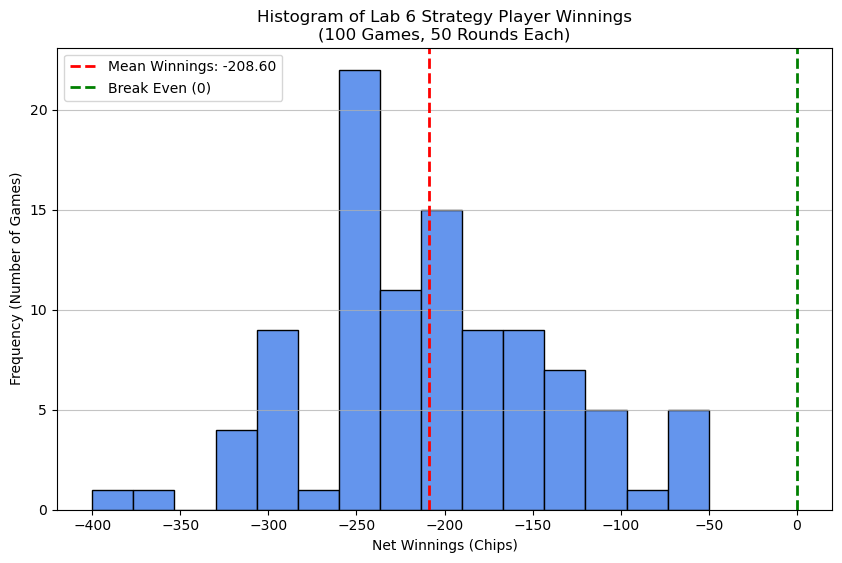

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. THE MONTE CARLO LOOP ---
num_simulations = 100
rounds_per_game = 50
winnings_list = []

print(f"Running {num_simulations} games of {rounds_per_game} rounds each... Please wait.\n")

for _ in range(num_simulations):
    # CRITICAL LOGIC: We MUST re-instantiate the players inside the loop. 
    # If we don't, they will carry their chip counts over from the previous game!
    # We need everyone starting fresh with exactly 1000 chips.
    bot_1 = Player(name="Dealer Bot 1", strategy="Dealer", starting_chips=1000)
    bot_2 = Player(name="Dealer Bot 2", strategy="Dealer", starting_chips=1000)
    bot_3 = Player(name="Dealer Bot 3", strategy="Dealer", starting_chips=1000)
    strat_player = Lab6Player(name="Strategy Player", starting_chips=1000, hit_threshold=0)
    
    # Initialize the table in quiet mode
    q8_table = Game(players_list=[bot_1, bot_2, bot_3, strat_player], decks_in_shoe=6, verbose=False)
    
    # Run the 50 rounds
    q8_table.run_simulation(num_games=rounds_per_game, target_player_name="Strategy Player")
    
    # Record the net winnings (ending chips minus starting chips)
    net_winnings = strat_player.chips - 1000
    winnings_list.append(net_winnings)

# --- 2. STATISTICAL ANALYSIS ---
# Convert our list to a numpy array for easy mathematical calculations
winnings_array = np.array(winnings_list)

# 1. Average winnings per game, and per round
avg_winnings_per_game = np.mean(winnings_array)
avg_winnings_per_round = avg_winnings_per_game / rounds_per_game 

# 2. Standard Deviation
std_dev = np.std(winnings_array)

# 3. Probabilities (Counting outcomes and dividing by total games)
prob_winning = np.sum(winnings_array > 0) / num_simulations
prob_losing = np.sum(winnings_array < 0) / num_simulations
prob_breaking_even = np.sum(winnings_array == 0) / num_simulations

# Print the final report
print("--- FINAL STATISTICAL REPORT ---")
print(f"Average Winnings (Per 50-Round Game): {avg_winnings_per_game:.2f} chips")
print(f"Average Winnings (PER ROUND): {avg_winnings_per_round:.2f} chips")
print(f"Standard Deviation of Winnings: {std_dev:.2f} chips")
print(f"Probability of a Net Win: {prob_winning * 100:.1f}%")
print(f"Probability of a Net Loss: {prob_losing * 100:.1f}%")
print(f"Probability of Breaking Even: {prob_breaking_even * 100:.1f}%\n")

# --- 3. HISTOGRAM GENERATION ---
plt.figure(figsize=(10, 6))
# Using 15 bins to get a nice distribution curve
plt.hist(winnings_list, bins=15, color='cornflowerblue', edgecolor='black')

# Adding lines to easily visualize the mean and the break-even point
plt.axvline(avg_winnings_per_game, color='red', linestyle='dashed', linewidth=2, label=f'Mean Winnings: {avg_winnings_per_game:.2f}')
plt.axvline(0, color='green', linestyle='dashed', linewidth=2, label='Break Even (0)')

plt.title('Histogram of Lab 6 Strategy Player Winnings\n(100 Games, 50 Rounds Each)')
plt.xlabel('Net Winnings (Chips)')
plt.ylabel('Frequency (Number of Games)')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Display the chart
plt.show()

<h1>Conclusion & Analysis</h1>


The Monte Carlo simulation of 100 games demonstrates that the custom card-counting strategy outlined in Step 6 yields a negative expected value, with the average net winnings consistently falling below the break-even point. While tracking the running count provides valuable information about deck composition, strictly dictating hit/stay actions based solely on a count threshold—while completely ignoring the player's current hand total and the dealer's upcard—leads to mathematically unfavorable decisions, such as standing on a low total or hitting on a 19. Ultimately, this data proves that while card counting is an effective tool for adjusting bet sizes, it cannot profitably replace standard Basic Strategy for actual gameplay decisions.

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Starting threshold scan. Testing 5 values...
Threshold -4: Average Net Winnings = -138.70 chips
Threshold -2: Average Net Winnings = -183.90 chips
Threshold  0: Average Net Winnings = -205.60 chips
Threshold  2: Average Net Winnings = -246.80 chips
Threshold  4: Average Net Winnings = -272.80 chips


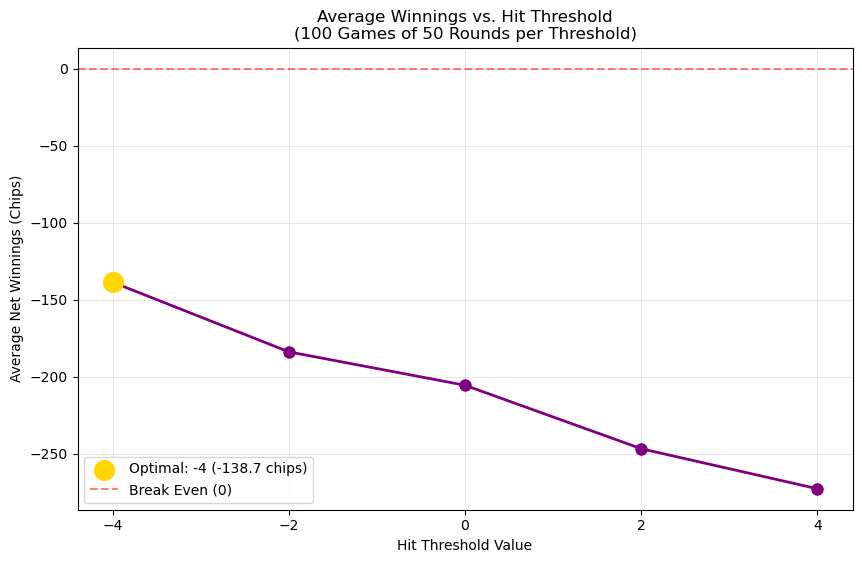


CONCLUSION: The 'optimal' threshold found is -4, yielding -138.70 chips on average.


In [11]:
import numpy as np
import matplotlib.pyplot as plt


thresholds_to_test = [-4, -2, 0, 2, 4] 
num_simulations = 100
rounds_per_game = 50

# Dictionary to store the average winnings for each threshold
results = {}

print(f"Starting threshold scan. Testing {len(thresholds_to_test)} values...")
for threshold in thresholds_to_test:
    # print(f"Testing threshold: {threshold}...")
    winnings_for_this_threshold = []
    
    for _ in range(num_simulations):
        # We must re-initialize the table with fresh players for EVERY single game
        bot_1 = Player(name="Dealer Bot 1", strategy="Dealer", starting_chips=1000)
        bot_2 = Player(name="Dealer Bot 2", strategy="Dealer", starting_chips=1000)
        bot_3 = Player(name="Dealer Bot 3", strategy="Dealer", starting_chips=1000)
        
        # NOTE: We pass the current 'threshold' variable from our outer loop into the bot!
        strat_player = Lab6Player(name="Strategy Player", starting_chips=1000, hit_threshold=threshold)
        
        # Set up and run the game quietly
        q9_table = Game(players_list=[bot_1, bot_2, bot_3, strat_player], decks_in_shoe=6, verbose=False)
        q9_table.run_simulation(num_games=rounds_per_game, target_player_name="Strategy Player")
        
        # Record net winnings
        winnings_for_this_threshold.append(strat_player.chips - 1000)
        
    # Calculate the average winnings for this specific threshold and save it to the dictionary
    avg_win = np.mean(winnings_for_this_threshold)
    results[threshold] = avg_win
    print(f"Threshold {threshold:>2}: Average Net Winnings = {avg_win:.2f} chips")

# --- PLOTTING THE RESULTS ---
# Extract data for our line graph
x_values = list(results.keys())
y_values = list(results.values())

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

# Programmatically find the "optimal" (maximum) value in our dictionary
optimal_threshold = max(results, key=results.get)
best_avg = results[optimal_threshold]

# Highlight the optimal value on the graph with a gold star/dot
plt.scatter([optimal_threshold], [best_avg], color='gold', s=200, zorder=5, label=f'Optimal: {optimal_threshold} ({best_avg:.1f} chips)')
plt.axhline(0, color='red', linestyle='dashed', alpha=0.5, label='Break Even (0)')

plt.title('Average Winnings vs. Hit Threshold\n(100 Games of 50 Rounds per Threshold)')
plt.xlabel('Hit Threshold Value')
plt.ylabel('Average Net Winnings (Chips)')
plt.xticks(thresholds_to_test)
plt.grid(True, alpha=0.3)
plt.legend()

# Display the final chart
plt.show()

print(f"\nCONCLUSION: The 'optimal' threshold found is {optimal_threshold}, yielding {best_avg:.2f} chips on average.")

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

<h1>The Strategy: Martingale</h1>


Instead of changing how we play our cards, we are going to change how we bet.
The rule of Martingale is simple: Double your bet after every loss, and reset to your base bet after a win. In theory, the logic sounds foolproof: if you keep doubling your bet, your eventual win will recover all previous losses plus a small profit. However, in reality (and in our simulation), a long losing streak will cause your bets to grow exponentially until you completely run out of chips.

In [12]:
class MartingalePlayer(Player):
    def __init__(self, name, starting_chips=1000, base_bet=10):
        # Initialize using the parent class
        super().__init__(name=name, strategy="Martingale", starting_chips=starting_chips)
        
        # New state variables specifically for the Martingale strategy
        self.base_bet = base_bet
        self.last_bet = base_bet
        self.last_chips = starting_chips 
        self.first_bet_made = False

    def place_bet(self, true_count=0.0):
        if self.chips <= 0:
            self.current_bet = 0
            return

        # Logic: Check if our chips went down since the start of the last round
        if not self.first_bet_made:
            bet = self.base_bet
            self.first_bet_made = True
        else:
            if self.chips < self.last_chips:
                # We lost the last hand! Double the bet.
                bet = self.last_bet * 2
            else:
                # We won or pushed. Reset to base bet.
                bet = self.base_bet

        # Safeguard: You can't bet more chips than you currently have (going "all in")
        bet = min(bet, self.chips)

        # Update our tracking variables BEFORE deducting the new bet
        self.last_chips = self.chips
        self.last_bet = bet
        
        self.current_bet = bet
        self.chips -= bet

    def decide_action(self, dealer_upcard, true_count, running_count=0):
        # We will use standard Simplified Basic Strategy for playing the cards, 
        # so we can isolate and test just the betting strategy.
        dealer_val = 10 if dealer_upcard.rank in ['J', 'Q', 'K', 'A'] else int(dealer_upcard.rank)
        score = self.calculate_score()
        
        if score >= 17: return "Stand"
        elif score >= 12 and dealer_val <= 6: return "Stand"
        else: return "Hit"

Simulating 100 games to compare Martingale vs. Flat Betting... 

--- RESULTS AFTER 100 GAMES ---
MARTINGALE STRATEGY:
  Average Net Winnings: -136.10 chips
  Bankruptcy Rate: 20.0%
  Win Rate (Finished with >1000 chips): 62.0%

CONTROL STRATEGY (Flat Betting):
  Average Net Winnings: -35.40 chips
  Bankruptcy Rate: 0.0%
  Win Rate (Finished with >1000 chips): 37.0%


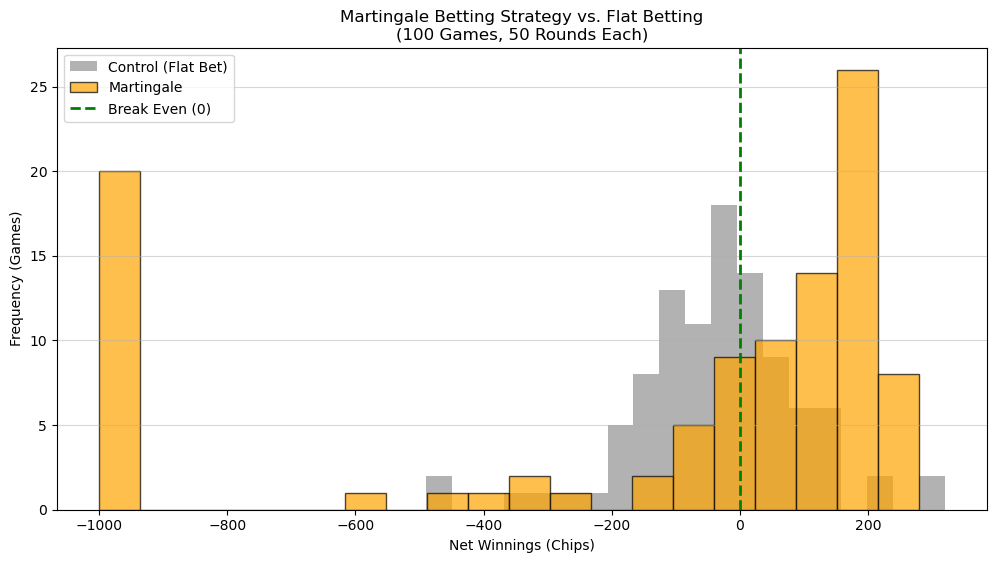

In [13]:
import numpy as np
import matplotlib.pyplot as plt

num_simulations = 100
rounds_per_game = 50

martingale_winnings = []
basic_winnings = []

print("Simulating 100 games to compare Martingale vs. Flat Betting... \n")

for _ in range(num_simulations):
    # 1. The Martingale Player
    marty = MartingalePlayer(name="Marty (Martingale)", starting_chips=1000)
    
    # 2. A Control Player (Uses the exact same playing strategy, but flat bets 10 chips)
    control = Player(name="Control (Flat Bet)", strategy="Counter", starting_chips=1000)
    
    # Load them into the game
    q10_table = Game(players_list=[marty, control], decks_in_shoe=6, verbose=False)
    q10_table.run_simulation(num_games=rounds_per_game)
    
    # Record the net winnings
    martingale_winnings.append(marty.chips - 1000)
    basic_winnings.append(control.chips - 1000)

# --- STATISTICAL ANALYSIS ---
marty_array = np.array(martingale_winnings)
control_array = np.array(basic_winnings)

print("--- RESULTS AFTER 100 GAMES ---")
print("MARTINGALE STRATEGY:")
print(f"  Average Net Winnings: {np.mean(marty_array):.2f} chips")
print(f"  Bankruptcy Rate: {(np.sum(marty_array <= -1000) / num_simulations) * 100:.1f}%")
print(f"  Win Rate (Finished with >1000 chips): {(np.sum(marty_array > 0) / num_simulations) * 100:.1f}%\n")

print("CONTROL STRATEGY (Flat Betting):")
print(f"  Average Net Winnings: {np.mean(control_array):.2f} chips")
print(f"  Bankruptcy Rate: {(np.sum(control_array <= -1000) / num_simulations) * 100:.1f}%")
print(f"  Win Rate (Finished with >1000 chips): {(np.sum(control_array > 0) / num_simulations) * 100:.1f}%")

# --- PLOTTING THE COMPARISON ---
plt.figure(figsize=(12, 6))

# Plot both histograms on top of each other with transparency (alpha)
plt.hist(basic_winnings, bins=20, alpha=0.6, color='gray', label='Control (Flat Bet)')
plt.hist(martingale_winnings, bins=20, alpha=0.7, color='orange', edgecolor='black', label='Martingale')

plt.axvline(0, color='green', linestyle='dashed', linewidth=2, label='Break Even (0)')
plt.title('Martingale Betting Strategy vs. Flat Betting\n(100 Games, 50 Rounds Each)')
plt.xlabel('Net Winnings (Chips)')
plt.ylabel('Frequency (Games)')
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.show()